<a href="https://colab.research.google.com/github/devarahaasan/Telecom-AI-Brand-Intelligence-System/blob/main/mainproj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom AI Brand Intelligence System

**Synthetic Dataset-1**

In [ ]:
# Step 0: Install necessary libraries
# !pip install pandas transformers torch tqdm

import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# Step 1: Load the synthetic dataset
# Make sure your file name matches the one in your Colab folder
try:
    df = pd.read_csv('/content/sample_Zends_synthetic_dataset.csv')
    print(" Data loaded successfully.")
except FileNotFoundError:
    print(" check the file name. CSV not found!")

# Step 2: Initialize the Sentiment Analysis model
# We use 'distilbert' because it is fast on CPU and very accurate
model_path = "distilbert-base-uncased-finetuned-sst-2-english"
sentiment_task = pipeline("sentiment-analysis", model=model_path, device=-1) # device=-1 means use CPU

print("Model is ready for action!")

 Data loaded successfully.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model is ready for action!


**check data quality**

In [ ]:

print("--- let's check the data quality! ---\n")

# 1. Check for Missing Values (Null values)
# If any column has nulls, we need to fix it
null_counts = df.isnull().sum()
print("1. Missing Values in each column:")
print(null_counts)
print("-" * 30)

# 2. Check for Duplicate Rows
# Duplicates can make the model biased (wrong results)
duplicate_count = df.duplicated().sum()
print(f"2. Number of Duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    print("   Action: We should remove these duplicates.")
print("-" * 30)

# 3. Check for Data Consistency (Sentiment labels)
# Let's see if there are any spelling mistakes in sentiment names
print("3. Unique values in Sentiment column:")
print(df['sentiment'].unique())
print("-" * 30)

# 4. Check Dataset Balance
# Let's see if we have enough data for all types (Positive, Negative, etc.)
print("4. Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("-" * 30)

# 5. Check for empty strings in text
# Sometimes text is not 'Null' but just a blank space ' '
empty_text = (df['text'].str.strip().fillna('') == '').sum()
print(f"5. Number of rows with empty text: {empty_text}")

--- let's check the data quality! ---

1. Missing Values in each column:
text            0
service_type    0
sentiment       0
dtype: int64
------------------------------
2. Number of Duplicate rows: 9850
   Action: We should remove these duplicates.
------------------------------
3. Unique values in Sentiment column:
['Positive' 'Negative' 'Neutral']
------------------------------
4. Sentiment Distribution:
sentiment
Negative    3341
Neutral     3340
Positive    3319
Name: count, dtype: int64
------------------------------
5. Number of rows with empty text: 0


**Synthetic Dataset-2**

In [ ]:
import random


adjectives_pos = ["excellent", "fantastic", "fast", "reliable", "smooth", "great"]
adjectives_neg = ["terrible", "slow", "bad", "poor", "frustrating"]
adjectives_neu = ["okay", "average", "normal", "fine"]

subjects = ["network", "internet", "billing", "support", "activation"]

categories = ["Mobile Network", "Broadband Service", "Billing & Payments", "Customer Support", "Service Activation"]

data = []

target_size = 10000

for i in range(target_size):
    category = random.choice(categories)
    sentiment = random.choice(["Positive", "Negative", "Neutral"])

    if sentiment == "Positive":
        text = f"{i} The {category} is {random.choice(adjectives_pos)} and {random.choice(subjects)} works great."
    elif sentiment == "Negative":
        text = f"{i} The {category} is {random.choice(adjectives_neg)} and I face issues with {random.choice(subjects)}."
    else:
        text = f"{i} The {category} is {random.choice(adjectives_neu)} and {random.choice(subjects)} is okay."

    data.append([text, category, sentiment])

df = pd.DataFrame(data, columns=['text', 'service_type', 'sentiment'])

df.to_csv('/content/final_unique_dataset.csv', index=False)



**Data quality check**

In [ ]:
print("--- DATA QUALITY CHECK ---\n")

# 1. Missing Values
print("1. Missing Values:")
print(df.isnull().sum())
print("-" * 40)

# 2. Duplicate Rows
duplicates = df.duplicated().sum()
print(f"2. Duplicate Rows: {duplicates}")
print("-" * 40)

# 3. Unique Values (Sentiment)
print("3. Unique Sentiment Values:")
print(df['sentiment'].unique())
print("-" * 40)

# 4. Sentiment Distribution
print("4. Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("-" * 40)

# 5. Service Category Distribution
print("5. Service Category Distribution:")
print(df['service_type'].value_counts())
print("-" * 40)

# 6. Empty Text Check
empty_text = (df['text'].str.strip() == '').sum()
print(f"6. Empty Text Rows: {empty_text}")
print("-" * 40)

# 7. Dataset Shape
print("7. Dataset Shape:", df.shape)

--- DATA QUALITY CHECK ---

1. Missing Values:
text            0
service_type    0
sentiment       0
dtype: int64
----------------------------------------
2. Duplicate Rows: 0
----------------------------------------
3. Unique Sentiment Values:
['Negative' 'Positive' 'Neutral']
----------------------------------------
4. Sentiment Distribution:
sentiment
Neutral     3366
Negative    3359
Positive    3275
Name: count, dtype: int64
----------------------------------------
5. Service Category Distribution:
service_type
Service Activation    2046
Billing & Payments    2016
Customer Support      1999
Mobile Network        1970
Broadband Service     1969
Name: count, dtype: int64
----------------------------------------
6. Empty Text Rows: 0
----------------------------------------
7. Dataset Shape: (10000, 3)


**EDA**

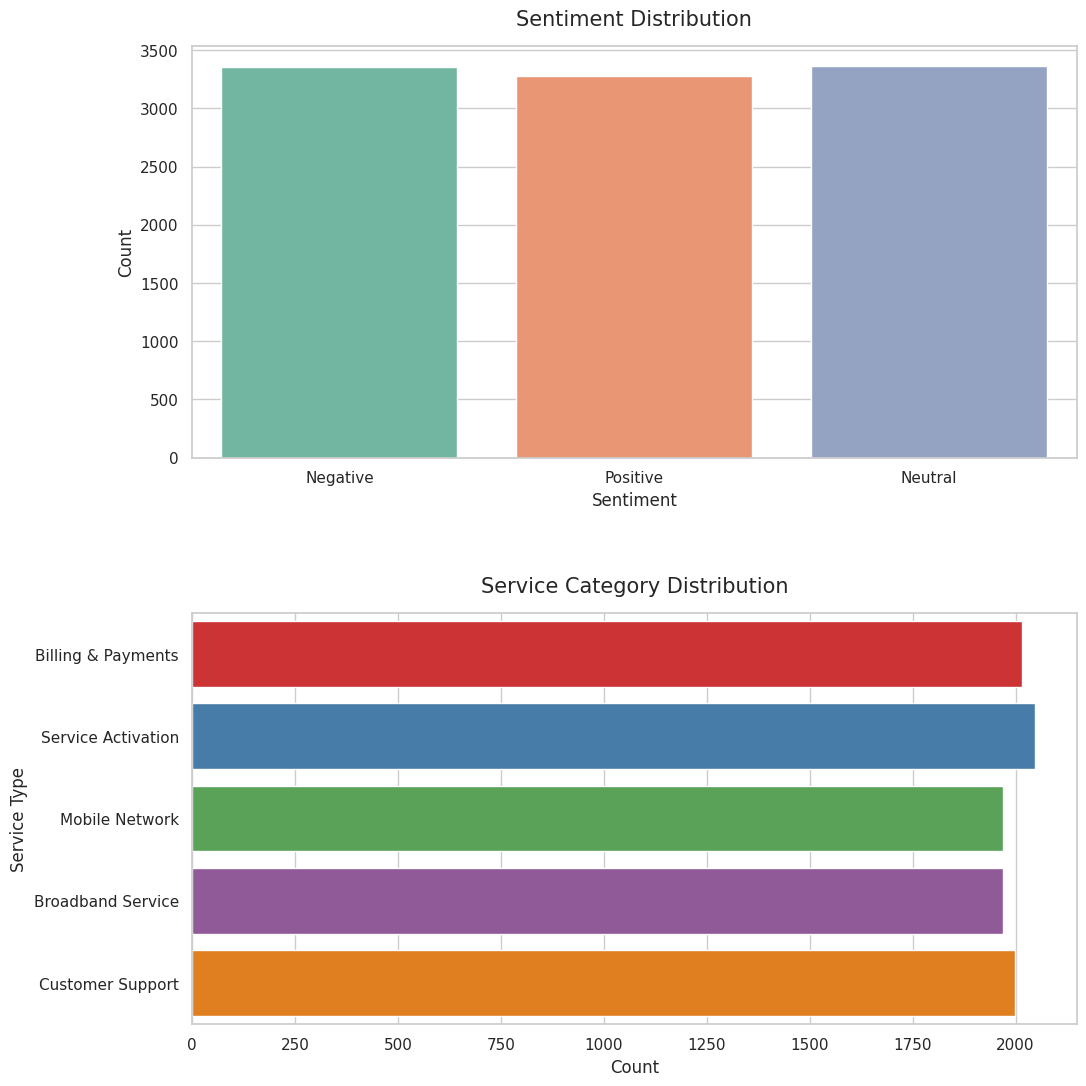

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/final_unique_dataset.csv')

# Style
sns.set(style="whitegrid")

# Create figure with more spacing
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# 1. Sentiment Distribution (Top)
sns.countplot(
    ax=axes[0],
    x='sentiment',
    data=df,
    hue='sentiment',
    palette='Set2',
    legend=False
)

axes[0].set_title("Sentiment Distribution", fontsize=15, pad=15)
axes[0].set_xlabel("Sentiment", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)

# 2. Service Category Distribution (Bottom)
sns.countplot(
    ax=axes[1],
    y='service_type',
    data=df,
    hue='service_type',
    palette='Set1',
    legend=False
)

axes[1].set_title("Service Category Distribution", fontsize=15, pad=15)
axes[1].set_xlabel("Count", fontsize=12)
axes[1].set_ylabel("Service Type", fontsize=12)

# Increase gap between plots
plt.tight_layout(pad=4.0)

plt.show()

**Sentiment Analysis(AI) - Model-1**

In [ ]:
from transformers import pipeline


# Load dataset
df = pd.read_csv('/content/final_unique_dataset.csv')

print("Loading AI Model...")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    device=-1
)

# Label mapping
def map_sentiment(label):
    if label == "LABEL_0":
        return "Negative"
    elif label == "LABEL_1":
        return "Neutral"
    elif label == "LABEL_2":
        return "Positive"

print("Running Sentiment Analysis...")

results = sentiment_pipeline(list(df['text']), batch_size=16)

df['ai_sentiment_result'] = [map_sentiment(r['label']) for r in results]

# Save output
df.to_csv('/content/final_sentiment_output.csv', index=False)

print("✅ Sentiment Analysis Completed!")

Loading AI Model...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Running Sentiment Analysis...
✅ Sentiment Analysis Completed!


**Model-1 Evaluation**

 MODEL PERFORMANCE
Accuracy: 66.43%

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00      3359
     NEUTRAL       1.00      0.00      0.01      3366
    POSITIVE       0.49      1.00      0.66      3275

    accuracy                           0.66     10000
   macro avg       0.83      0.67      0.56     10000
weighted avg       0.83      0.66      0.55     10000



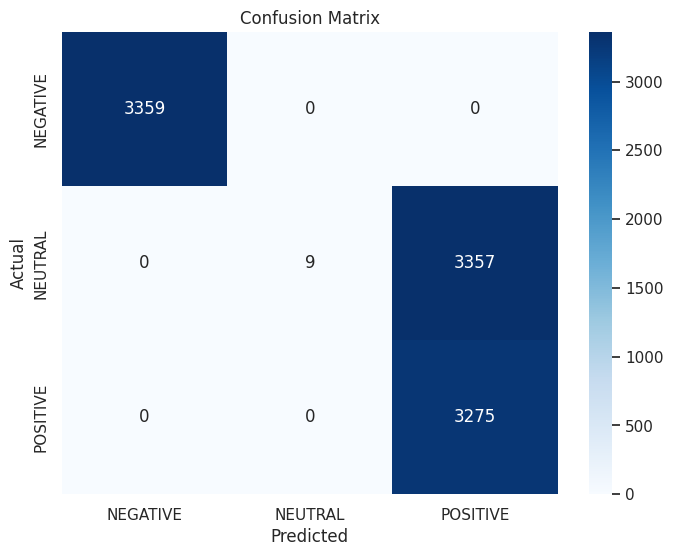

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load AI output file
df_results = pd.read_csv('/content/final_sentiment_output.csv')

# Convert to uppercase (avoid mismatch)
df_results['sentiment'] = df_results['sentiment'].str.upper()
df_results['ai_sentiment_result'] = df_results['ai_sentiment_result'].str.upper()

#  Accuracy
accuracy = accuracy_score(df_results['sentiment'], df_results['ai_sentiment_result'])

print(" MODEL PERFORMANCE")
print(f"Accuracy: {round(accuracy*100, 2)}%")

#  Detailed Report
print("\nClassification Report:")
print(classification_report(df_results['sentiment'], df_results['ai_sentiment_result']))

#  Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(df_results['sentiment'], df_results['ai_sentiment_result'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NEGATIVE','NEUTRAL','POSITIVE'],
            yticklabels=['NEGATIVE','NEUTRAL','POSITIVE'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Sentiment Analysis(AI) - Model-2**

In [ ]:

#  1. Load Dataset
df = pd.read_csv('/content/final_unique_dataset.csv')

print("Dataset Loaded:", df.shape)

# 2. Load Model
print("Loading Model...")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=-1
)

#  3. Map Model Output to Labels
def map_sentiment(label):
    stars = int(label[0])   # '1 star', '2 stars', etc.

    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

#  4. Run Sentiment Analysis
results = []

print("Running Sentiment Analysis...")

for text in tqdm(df['text']):
    res = sentiment_pipeline(text)
    label = res[0]['label']
    results.append(map_sentiment(label))

#  5. Save Results
df['ai_sentiment_result'] = results

df.to_csv('/content/final_sentiment2_output.csv', index=False)

print("Sentiment Analysis Completed!")
print(df.head())

Dataset Loaded: (10000, 3)
Loading Model...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Running Sentiment Analysis...


100%|██████████| 10000/10000 [19:27<00:00,  8.57it/s]

Sentiment Analysis Completed!
                                                text        service_type  \
0  0 The Billing & Payments is frustrating and I ...  Billing & Payments   
1  1 The Billing & Payments is fantastic and netw...  Billing & Payments   
2  2 The Service Activation is smooth and network...  Service Activation   
3  3 The Billing & Payments is bad and I face iss...  Billing & Payments   
4  4 The Mobile Network is great and network work...      Mobile Network   

  sentiment ai_sentiment_result  
0  Negative            Negative  
1  Positive            Positive  
2  Positive            Positive  
3  Negative            Negative  
4  Positive            Positive  


**Model-2 Evaluation**

FINAL MODEL PERFORMANCE
Accuracy: 98.78%

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       1.00      1.00      1.00      3359
     NEUTRAL       1.00      0.96      0.98      3366
    POSITIVE       0.96      1.00      0.98      3275

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



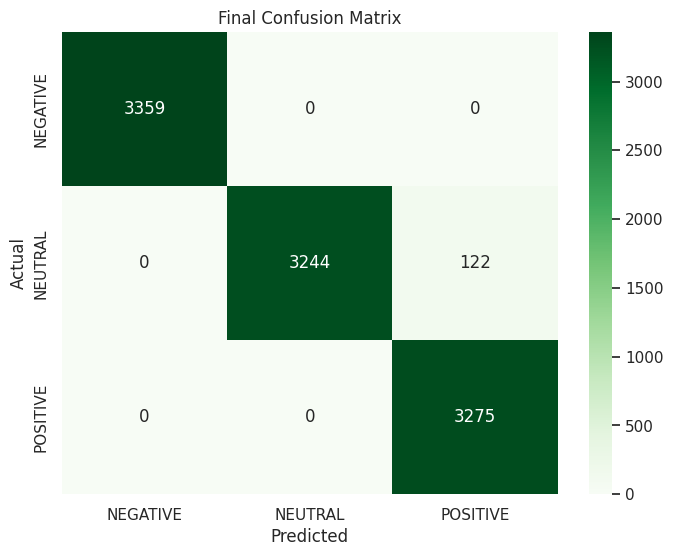

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df_results = pd.read_csv('/content/final_sentiment2_output.csv')

df_results['sentiment'] = df_results['sentiment'].str.upper()
df_results['ai_sentiment_result'] = df_results['ai_sentiment_result'].str.upper()

# Accuracy
accuracy = accuracy_score(df_results['sentiment'], df_results['ai_sentiment_result'])

print("FINAL MODEL PERFORMANCE")
print(f"Accuracy: {round(accuracy*100, 2)}%")

# Report
print("\nClassification Report:")
print(classification_report(df_results['sentiment'], df_results['ai_sentiment_result']))

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(df_results['sentiment'], df_results['ai_sentiment_result'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['NEGATIVE','NEUTRAL','POSITIVE'],
            yticklabels=['NEGATIVE','NEUTRAL','POSITIVE'])

plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Cross Validation (model-2)**

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


# Load data
df = pd.read_csv('/content/final_sentiment2_output.csv')

# Load model
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=-1
)

# Mapping
def map_sentiment(label):
    stars = int(label[0])
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

print("Running 5-Fold Cross Validation...\n")

for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
    print(f"Fold {fold+1}")

    test_data = df.iloc[test_idx]

    preds = []

    for text in test_data['text']:
        res = sentiment_pipeline(text)
        preds.append(map_sentiment(res[0]['label']))

    acc = accuracy_score(test_data['sentiment'], preds)
    print(f"Accuracy: {round(acc*100,2)}%\n")

    accuracies.append(acc)

# Final average
print(" FINAL CROSS VALIDATION RESULT")
print(f"Average Accuracy: {round(sum(accuracies)/len(accuracies)*100,2)}%")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running 5-Fold Cross Validation...

Fold 1
Accuracy: 99.0%

Fold 2
Accuracy: 98.85%

Fold 3
Accuracy: 98.7%

Fold 4
Accuracy: 98.5%

Fold 5
Accuracy: 98.85%

 FINAL CROSS VALIDATION RESULT
Average Accuracy: 98.78%


**Retrieval-Augmented Generation (RAG)**


In [ ]:
# 1. Install Libraries
!pip install sentence-transformers faiss-cpu

# 2. Import Libraries
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer


# 3. Create Documents (Knowledge Base)
documents = [
    "Customers facing network issues should restart their device and check signal strength.",
    "Billing complaints must be resolved within 24 hours of request.",
    "Slow internet issues can be resolved by restarting the router and checking bandwidth usage.",
    "Customer support agents must respond politely and resolve issues quickly.",
    "Service activation may take up to 2 hours after SIM insertion."
]


# 4. Load Embedding Model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')


# 5. Convert Documents → Embeddings
doc_embeddings = embedding_model.encode(documents)
doc_embeddings = np.array(doc_embeddings)


# 6. Create FAISS Vector Database
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(doc_embeddings)

print("FAISS index created successfully!")


#7. Retrieval Function
def retrieve_context(query):
    query_embedding = embedding_model.encode([query])
    query_embedding = np.array(query_embedding)

    distances, indices = index.search(query_embedding, k=1)

    return documents[indices[0][0]]


# 8. Generate Response
def generate_response(query):
    context = retrieve_context(query)

    response = f"""
 Customer Query:
{query}

 Relevant Policy:
{context}

AI Response:
We understand your concern. {context} Please follow the above steps to resolve your issue.
"""

    return response

# 9. Test the RAG System
query = "My internet is very slow"

print(generate_response(query))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.0 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS index created successfully!

 Customer Query:
My internet is very slow

 Relevant Policy:
Slow internet issues can be resolved by restarting the router and checking bandwidth usage.

AI Response:
We understand your concern. Slow internet issues can be resolved by restarting the router and checking bandwidth usage. Please follow the above steps to resolve your issue.



**Save models**

In [ ]:
!pip install joblib

In [ ]:
import joblib

# Save as pkl
joblib.dump(sentiment_pipeline, "sentiment_pipeline.pkl")


print(" Model saved as sentiment_pipeline .pkl")

 Model saved as sentiment_pipeline .pkl


In [ ]:
# Save FAISS index
faiss.write_index(index, "faiss_index.bin")

# Save documents
joblib.dump(documents, "documents.pkl")

print(" RAG saved successfully!")

 RAG saved successfully!


**Streamlit Application**

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-04-10 16:15:21--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-04-10 16:15:21--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-10T16%3A58%3A21Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-10T1

In [ ]:
!pip install streamlit-option-menu

In [ ]:
%%writefile AI.py

import streamlit as st
import joblib
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# -------------------- 🎨 CUSTOM BLACK THEME --------------------
st.markdown("""
    <style>
    /* full background */
    .stApp {
        background-color: #0E1117;
        color: white;
    }

    /* all text */
    html, body, [class*="css"] {
        color: white !important;
    }

    /* textarea */
    textarea {
        background-color: #1E1E1E !important;
        color: white !important;
    }

    /* input box */
    input {
        color: white !important;
        background-color: #1E1E1E !important;
    }

    /* button */
    .stButton>button {
        background-color: #00ADB5;
        color: white;
        border-radius: 8px;
        height: 3em;
        width: 100%;
        font-size: 16px;
    }

    .stButton>button:hover {
        background-color: #007B83;
        color: white;
    }

    /* headings */
    h1, h2, h3, h4, h5, h6 {
        color: white !important;
    }

    /* labels */
    label {
        color: white !important;
    }

    /* success/info boxes */
    .stAlert {
        color: white !important;
    }

    </style>
""", unsafe_allow_html=True)

# -------------------- 📡 TITLE --------------------
st.title("📡 Telecom AI Brand Intelligence System")
st.write("Analyze customer feedback using AI 🚀")

# -------------------- 🔄 LOAD MODELS --------------------
@st.cache_resource
def load_models():
    sentiment_pipeline = joblib.load("sentiment_pipeline.pkl")
    index = faiss.read_index("faiss_index.bin")
    documents = joblib.load("documents.pkl")
    embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

    return sentiment_pipeline, index, documents, embedding_model

sentiment_pipeline, index, documents, embedding_model = load_models()

# -------------------- 🧠 FUNCTIONS --------------------
def map_sentiment(label):
    stars = int(label[0])
    if stars <= 2:
        return "Negative"
    elif stars == 3:
        return "Neutral"
    else:
        return "Positive"

def classify_service_category(text):
    text = text.lower()
    if any(word in text for word in ["billing", "payment", "charge"]):
        return "Billing & Payments"
    elif any(word in text for word in ["network", "signal", "call"]):
        return "Mobile Network"
    elif any(word in text for word in ["internet", "wifi", "router"]):
        return "Broadband Service"
    elif any(word in text for word in ["support", "agent", "help"]):
        return "Customer Support"
    elif any(word in text for word in ["activate", "sim"]):
        return "Service Activation"
    else:
        return "General Inquiry"

def retrieve_context(query):
    q_embed = embedding_model.encode([query])
    q_embed = np.array(q_embed)
    D, I = index.search(q_embed, k=1)
    return documents[I[0][0]]

# -------------------- 💬 USER INPUT --------------------
user_input = st.text_area("💬 Enter Customer Feedback")

# -------------------- 🚀 ANALYZE BUTTON --------------------
if st.button("Analyze Feedback"):

    if user_input.strip() == "":
        st.warning("⚠️ Please enter feedback!")
    else:
        # Sentiment
        sentiment_raw = sentiment_pipeline(user_input)[0]['label']
        sentiment = map_sentiment(sentiment_raw)

        # Topic
        topic = classify_service_category(user_input)

        # RAG
        solution = retrieve_context(user_input)

        # -------------------- 📊 OUTPUT --------------------
        st.markdown("### 🔍 Analysis Result")

        col1, col2 = st.columns(2)

        col1.success(f"📊 Sentiment: {sentiment}")
        col2.info(f"📡 Category: {topic}")

        st.markdown("### 💡 Suggested Solution")
        st.write(solution)

        st.markdown("---")
        st.caption("🚀 Powered by AI | RAG + NLP System")

In [ ]:
!streamlit run /content/AI.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"